# Título do Projeto: Projeto Preço de Roupas
**Autor(a):** Natali Mendonça Dau

**Data:** 18.03.2026

**Objetivo:** Analisar e examinar os dados das roupas para prever seus valores, baseados em marcas, cores, etc.

---
## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

---
## 2. Carregamento dos Dados
- **Fonte dos dados:** https://www.kaggle.com/datasets/mrsimple07/clothes-price-prediction

---
## 3. Análise Exploratória de Dados (EDA)

In [2]:
df = pd.read_csv('data/clothes_price_prediction_data.csv')
df.head(20)

,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113
5,Reebok,Jacket,Red,XL,Nylon,19
6,Puma,Jacket,Red,XXL,Polyester,31
7,Adidas,Dress,Red,XS,Denim,46
8,Reebok,Dress,Black,S,Wool,97
9,Adidas,Jeans,Yellow,L,Wool,80


---
## 4. Pré-processamento e Limpeza de Dados

In [3]:
df.describe()

,Price
count,1000.000000
mean,106.289000
std,53.695444
min,10.000000
25%,59.750000
50%,108.000000
75%,150.000000
max,199.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Brand     1000 non-null   str  
 1   Category  1000 non-null   str  
 2   Color     1000 non-null   str  
 3   Size      1000 non-null   str  
 4   Material  1000 non-null   str  
 5   Price     1000 non-null   int64
dtypes: int64(1), str(5)
memory usage: 47.0 KB


In [32]:
maior = df['Preco'].max()

menor = df['Preco'].min()

print("Maior:", maior)
print("Menor:", menor)

Maior: 199
Menor: 10


In [33]:
media = df['Preco'].mean()

mediana = df['Preco'].median()

moda = df['Preco'].mode()[0]

print("Média:",media)
print("Mediana:",mediana)
print("Moda:",moda)

Média: 106.289
Mediana: 108.0
Moda: 97


In [34]:
df.isnull().sum()

Marca                     0
Categoria                 0
Cor                       0
Tamanho                   0
Material                  0
Preco                     0
Marca_LabelEncoder        0
Categoria_LabelEncoder    0
Cor_LabelEncoder          0
Tamanho_LabelEncoder      0
Material_LabelEncoder     0
dtype: int64

---
## 5. Engenharia de Atributos (Feature Engineering)

In [5]:
colunas = {
    'Brand': 'Marca',
    'Category': 'Categoria',
    'Color': 'Cor',
    'Size': 'Tamanho',
    'Price': 'Preco'
}

df = df.rename(columns=colunas)
df.head(20)

,Marca,Categoria,Cor,Tamanho,Material,Preco
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113
5,Reebok,Jacket,Red,XL,Nylon,19
6,Puma,Jacket,Red,XXL,Polyester,31
7,Adidas,Dress,Red,XS,Denim,46
8,Reebok,Dress,Black,S,Wool,97
9,Adidas,Jeans,Yellow,L,Wool,80


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Marca_LabelEncoder'] = le.fit_transform(df['Marca'])
df['Categoria_LabelEncoder'] = le.fit_transform(df['Categoria'])
df['Cor_LabelEncoder'] = le.fit_transform(df['Cor'])
df['Tamanho_LabelEncoder'] = le.fit_transform(df['Tamanho'])
df['Material_LabelEncoder'] = le.fit_transform(df['Material'])

df

,Marca,Categoria,Cor,Tamanho,Material,Preco,Marca_LabelEncoder,Categoria_LabelEncoder,Cor_LabelEncoder,Tamanho_LabelEncoder,Material_LabelEncoder
0,New Balance,Dress,White,XS,Nylon,182,1,0,4,4,2
1,New Balance,Jeans,Black,XS,Silk,57,1,2,0,4,4
2,Under Armour,Dress,Red,M,Wool,127,5,0,3,1,5
3,Nike,Shoes,Green,M,Cotton,77,2,3,2,1,0
4,Adidas,Sweater,White,M,Nylon,113,0,4,4,1,2
...,...,...,...,...,...,...,...,...,...,...,...
995,Puma,Jeans,Black,L,Polyester,176,3,2,0,0,3
996,Puma,Jacket,Red,XXL,Silk,110,3,1,3,5,4
997,Reebok,Sweater,Blue,XS,Denim,127,4,4,1,4,1
998,Under Armour,Sweater,Black,XXL,Denim,69,5,4,0,5,1


In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(df[['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material']])

encoded_df = df

encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material']))

encoded_df['Preco'] = df['Preco']

encoded_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Marca_Adidas        1000 non-null   float64
 1   Marca_New Balance   1000 non-null   float64
 2   Marca_Nike          1000 non-null   float64
 3   Marca_Puma          1000 non-null   float64
 4   Marca_Reebok        1000 non-null   float64
 5   Marca_Under Armour  1000 non-null   float64
 6   Categoria_Dress     1000 non-null   float64
 7   Categoria_Jacket    1000 non-null   float64
 8   Categoria_Jeans     1000 non-null   float64
 9   Categoria_Shoes     1000 non-null   float64
 10  Categoria_Sweater   1000 non-null   float64
 11  Categoria_T-shirt   1000 non-null   float64
 12  Cor_Black           1000 non-null   float64
 13  Cor_Blue            1000 non-null   float64
 14  Cor_Green           1000 non-null   float64
 15  Cor_Red             1000 non-null   float64
 16  Cor_White         

---
## 6. Divisão dos Dados

In [8]:
y = df['Preco']

x = df.drop(columns=['Marca', 'Categoria', 'Cor', 'Tamanho', 'Material', 'Preco'])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train.shape[0]

800

In [9]:
Y = encoded_df['Preco']

X = encoded_df.drop(columns=['Preco'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train.shape[0]

800

---
## 7. Modelagem (Machine Learning)

In [ ]:
modelo_linear = LinearRegression()
modelo_arvore = RandomForestRegressor(random_state=42)

modelo_linear.fit(x_train, y_train)
modelo_arvore.fit(x_train, y_train)

previsoes_linear = modelo_linear.predict(x_test)
previsoes_arvore = modelo_arvore.predict(x_test)

In [27]:
modelo_linear1 = LinearRegression()
modelo_arvore1 = RandomForestRegressor(random_state=42)

modelo_linear1.fit(X_train, Y_train)
modelo_arvore1.fit(X_train, Y_train)

previsoes_linear1 = modelo_linear1.predict(X_test)
previsoes_arvore1 = modelo_arvore1.predict(X_test)

---
## 8. Avaliação e Validação do Modelo

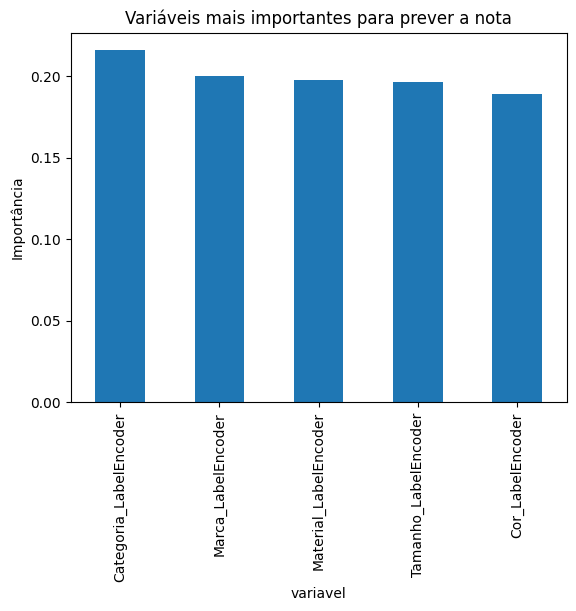

In [13]:
import pandas as pd

importances = modelo_arvore.feature_importances_

df_importancia = pd.DataFrame({
    "variavel": x_train.columns,
    "importancia": importances
}).sort_values("importancia", ascending=False)

df_importancia.head(10).plot.bar(x="variavel", y="importancia", legend=False)

plt.title("Variáveis mais importantes para prever a nota")
plt.ylabel("Importância")

plt.show()

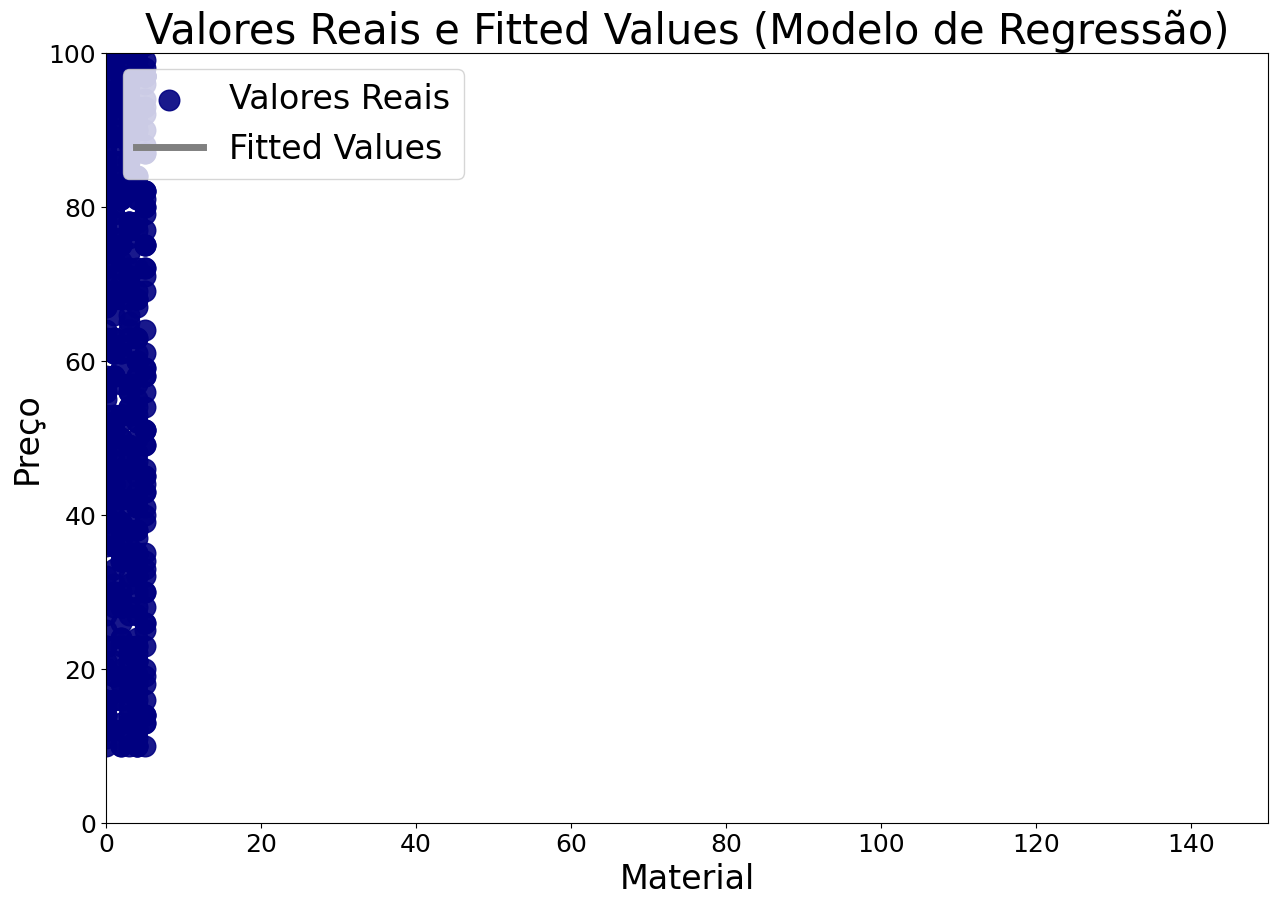

In [ ]:
plt.figure(figsize=(15,10))
sns.regplot(data=df, x='Material_LabelEncoder', y='Preco', marker='o', ci=False,
            scatter_kws={"color":'navy', 'alpha':0.9, 's':220},
            line_kws={"color":'grey', 'linewidth': 5})
plt.title('Valores Reais e Fitted Values (Modelo de Regressão)', fontsize=30)
plt.xlabel('Material', fontsize=24)
plt.ylabel('Preço', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0, 150)
plt.ylim(0, 100)
plt.legend(['Valores Reais', 'Fitted Values'], fontsize=24, loc='upper left')
plt.show()

<Axes: >

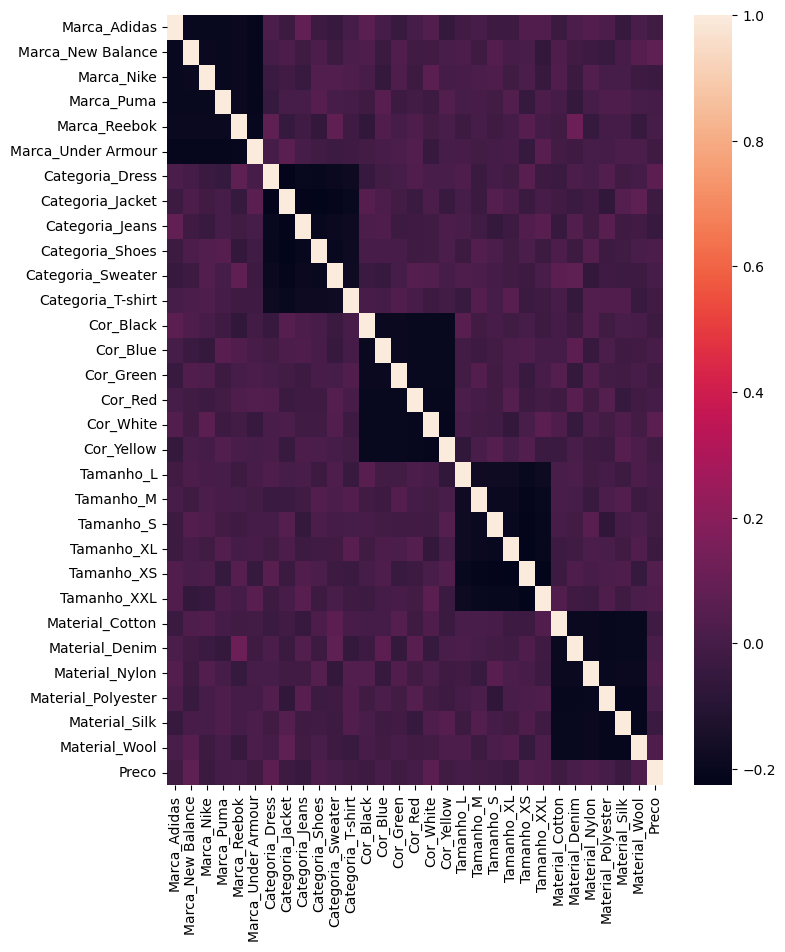

In [31]:
importances1 = modelo_arvore1.feature_importances_

plt.figure(figsize=(8, 10))

corr = encoded_df.select_dtypes('number').corr()

sns.heatmap(corr)

---
## 9. Interpretabilidade do Modelo

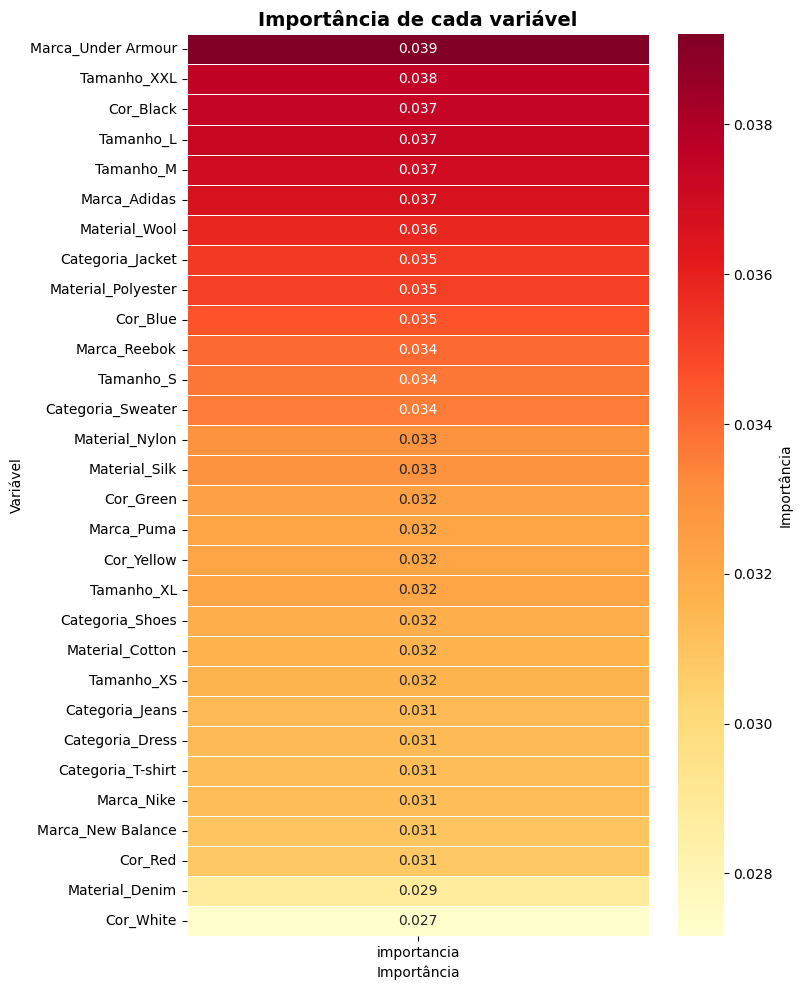

In [30]:
importances1 = modelo_arvore1.feature_importances_

df_importancia1 = pd.DataFrame({
    "variavel": X_train.columns,
    "importancia": importances1
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(8, 10))

sns.heatmap(
    df_importancia1.set_index("variavel"), 
    annot=True,
    fmt=".3f",  
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Importância"}
)

plt.title("Importância de cada variável", fontsize=14, fontweight="bold")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [26]:
erro_linear = mean_absolute_error(y_test, previsoes_linear)
print(erro_linear)

erro_arvore = mean_absolute_error(y_test, previsoes_arvore)
print(erro_arvore)

46.51755838640627
48.583489642857145


In [29]:
erro_linear1 = mean_absolute_error(Y_test, previsoes_linear1)
print(erro_linear1)

erro_arvore1 = mean_absolute_error(Y_test, previsoes_arvore1)
print(erro_arvore1)

46.32198766323365
47.551770873015876


---
## 10. Conclusão e Próximos Passos
- **Resumo dos Resultados:** O modelo não respondeu a proposta, não sendo capaz de identificar o peso/valor de cada variável pela ausência de informações sobre os dados e suas especificações. Mesmo utilizando o modelo corretamente, ele não foi capaz de identificar padrões, dado que os dados não possuem uma informação clara sobre a importância e separação de cada categoria e item, resultando em um tratamento confuso dos mesmos.